# CICE `uatm`/`vatm` rotation check — FOSI_BGC HR (t13 grid)

Purpose: figure out, empirically, whether `uatm`/`vatm` from the CICE history
files are usable as-is or need rotation before going into the ML pipeline.

Run this on Casper with `/glade/campaign` and `/glade/p` mounted.

Steps:
1. Confirm which frequencies exist (`tseries/month_1`, `tseries/day_1`) and whether
   `uatm`/`vatm` were saved at each — one-variable-per-file layout, so this means
   checking filenames, not opening one file and expecting everything in it.
2. Inspect var attrs, grid location (T vs U), and whether `ANGLE`/`ANGLET` are present.
3. Apply the ANGLET rotation.
4. Sanity-check the rotation direction at a known coastal point before trusting it basin-wide.
5. (If needed) regrid rotated true-E/N components with xESMF, same weights as the rest of the pipeline.

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

RUN_DIR = Path("/glade/campaign/cgd/oce/projects/FOSI_BGC/HR/g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001/")
FORCING_DIR = Path("/glade/p/cesmdata/cseg/inputdata/ocn/jra55/v1.5_noleap")

## 1. What history streams exist?

Confirmed layout for this run: `ice/proc/tseries/` has both `month_1` and `day_1`
subdirectories, each with one file per variable (e.g. `*.cice.h.uatm.YYYYMM-YYYYMM.nc`).
No raw `ice/hist/` — only the processed tseries directories. So the frequency question
is really "does `day_1` include uatm/vatm", not "does daily data exist at all".

In [3]:
# One directory per frequency, discovered directly rather than assumed
TSERIES_DIR = RUN_DIR / "ice" / "proc" / "tseries"
freq_dirs = {p.name: p for p in TSERIES_DIR.iterdir() if p.is_dir()}
print(freq_dirs)

{'month_1': PosixPath('/glade/campaign/cgd/oce/projects/FOSI_BGC/HR/g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001/ice/proc/tseries/month_1'), 'day_1': PosixPath('/glade/campaign/cgd/oce/projects/FOSI_BGC/HR/g.e22.TL319_t13.G1850ECOIAF_JRA_HR.4p2z.001/ice/proc/tseries/day_1')}


In [4]:
# Group files within each frequency dir by variable name (.uatm., .vatm., .Tsfc., ...)
import re
from collections import defaultdict

streams = {}  # streams[freq][varname] = list of files
for freq, d in freq_dirs.items():
    by_var = defaultdict(list)
    for f in sorted(d.glob("*.nc")):
        m = re.search(r"\.cice\.h\d*\.([^.]+)\.", f.name)
        if m:
            by_var[m.group(1)].append(f)
    streams[freq] = by_var
    print(f"{freq}: {len(by_var)} variables, e.g. {list(by_var)[:8]}")

month_1: 66 variables, e.g. ['Tsfc', 'aice', 'aicen', 'albsni', 'alidf_ai', 'alidr_ai', 'alvdf_ai', 'alvdr_ai']
day_1: 23 variables, e.g. ['aice_d', 'congel_d', 'daidtd_d', 'daidtt_d', 'dvidtd_d', 'dvidtt_d', 'fcondtop_ai_d', 'flat_d']


In [5]:
# Does day_1 actually include uatm/vatm, or was it trimmed relative to month_1?
for freq in freq_dirs:
    has_u = "uatm" in streams[freq]
    has_v = "vatm" in streams[freq]
    print(f"{freq}: uatm={has_u}, vatm={has_v}")

month_1: uatm=True, vatm=True
day_1: uatm=False, vatm=False


## 2. Inspect `uatm`/`vatm` and the angle variables

Confirm:
- grid location of `uatm`/`vatm` (should be T-cell per CICE docs)
- whether `ANGLE` (U-point) and/or `ANGLET` (T-point) are present
- units / long_name / any comment about rotation, so we're not assuming

In [6]:
# uatm/vatm live in their own files; ANGLE/ANGLET aren't in those files at all
# (they're static grid vars, only written to whichever file CICE dumped grid info into —
# use the Step-2 `ds` from your first exploration, or any file that has them).
FREQ = "month_1"  # switch to "day_1" once you've confirmed uatm/vatm are actually there

uatm_files = streams[FREQ]["uatm"]
vatm_files = streams[FREQ]["vatm"]

ds_grid = xr.open_dataset(freq_dirs[FREQ] / next(iter(streams[FREQ].values()))[0])
# ^ grabs whichever file happens to carry ANGLE/ANGLET; replace with a known-good
#   grid/domain file path if none of the tseries files carry it

for v in ["ANGLE", "ANGLET"]:
    if v in ds_grid:
        print(f"--- {v} ---")
        print(ds_grid[v].attrs)
    else:
        print(f"{v} NOT in this file")

ds_u = xr.open_mfdataset(uatm_files, combine="by_coords")
ds_v = xr.open_mfdataset(vatm_files, combine="by_coords")
print(ds_u["uatm"].attrs)
print(ds_v["vatm"].attrs)

--- ANGLE ---
{'long_name': 'angle grid makes with latitude line on U grid', 'units': 'radians'}
--- ANGLET ---
{'long_name': 'angle grid makes with latitude line on T grid', 'units': 'radians'}
{'units': 'm/s', 'long_name': 'atm velocity (x)', 'cell_measures': 'area: uarea', 'cell_methods': 'time: mean', 'time_rep': 'averaged'}
{'units': 'm/s', 'long_name': 'atm velocity (y)', 'cell_measures': 'area: uarea', 'cell_methods': 'time: mean', 'time_rep': 'averaged'}


**Checkpoint:** if `ANGLET` is missing but `ANGLE` is present, don't substitute `ANGLE`
directly — `uatm`/`vatm` are T-cell fields, and using the U-point angle introduces a
spatial offset. Either compute/derive `ANGLET` from the grid file, or pull it from the
grid/domain file for this case (`grid_file` in the CICE namelist) rather than the history file.

In [7]:
angle_var = "ANGLET" if "ANGLET" in ds_grid else "ANGLE"
print("Using:", angle_var, "- confirm this is really T-grid before trusting downstream results")

angle = ds_grid[angle_var]
u_geo = ds_u["uatm"] * np.cos(angle) - ds_v["vatm"] * np.sin(angle)
v_geo = ds_u["uatm"] * np.sin(angle) + ds_v["vatm"] * np.cos(angle)

Using: ANGLET - confirm this is really T-grid before trusting downstream results


## 3. Sanity check the rotation direction

Pick a coastal Arctic point with a known/expected wind pattern and compare raw vs rotated
vectors on a map. If the rotated arrows don't point the way local climatology says they
should, the sign convention or angle variable is wrong — fix that before running this at
scale, not after.

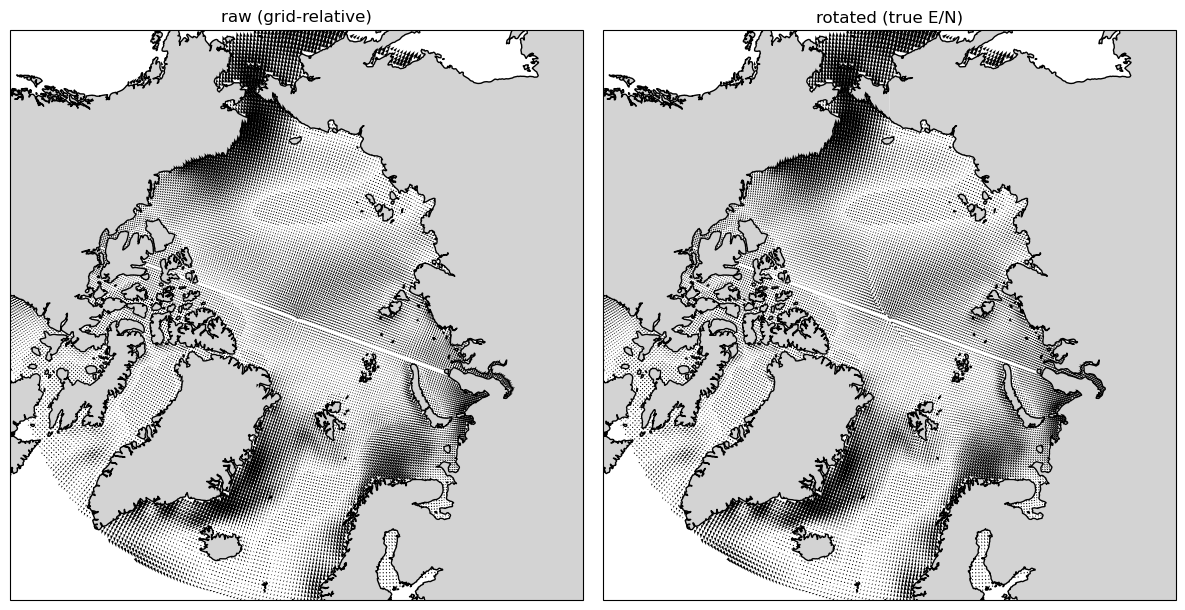

In [9]:
# Update these to a point you actually know the expected wind behavior for
# e.g. one of your existing candidate points (Kivalina, Shishmaref, Kotzebue)
check_lat, check_lon = 67.7, -164.5  # placeholder - Kotzebue area

t = 0  # time index to inspect
lat_min = 60  # only plot the Arctic portion of the global tripole array
step = 6  # subsample so arrows aren't overplotted


def prep_quiver(u, v, tlon, tlat, lat_min=lat_min, step=step):
    """Flatten + mask to finite Arctic points. Avoids cartopy's regrid_shape,
    which calls scipy.griddata and crashes on any NaN (land mask, grid seam)."""
    sl = (slice(None, None, step), slice(None, None, step))
    lon, lat = tlon.values[sl], tlat.values[sl]
    uu, vv = u.values[sl], v.values[sl]
    mask = (lat > lat_min) & np.isfinite(lon) & np.isfinite(lat) & np.isfinite(uu) & np.isfinite(vv)
    return lon[mask], lat[mask], uu[mask], vv[mask]


fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                          subplot_kw={"projection": ccrs.NorthPolarStereo()})

for ax, (uf, vf, title) in zip(
    axes,
    [(ds_u["uatm"], ds_v["vatm"], "raw (grid-relative)"),
     (u_geo, v_geo, "rotated (true E/N)")]
):
    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.coastlines()
    x, y, uu, vv = prep_quiver(uf.isel(time=t), vf.isel(time=t),
                                ds_grid["TLON"], ds_grid["TLAT"])
    ax.quiver(x, y, uu, vv, transform=ccrs.PlateCarree())
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 4. Next: regrid rotated components onto EASE2

Rotate first (above), *then* regrid — regridding raw grid-relative components would
interpolate across cells with different local angles and smear the vector direction.

Reuse the existing xESMF weights (`/glade/work/skygale/_projects/SeaIceDownscaling/regrid_weights/`)
if a t13 T-grid → EASE2 weight file already exists; otherwise this pair needs a new
conservative weight file, same as the other coarsening steps in `functions/regrid.py`.

In [ ]:
# import xesmf as xe
#
# regridder = xe.Regridder(ds_grid[["TLAT", "TLON"]], target_grid, method="bilinear",
#                           weights="/path/to/t13_to_ease2_weights.nc")
# u_geo_ease2 = regridder(u_geo)
# v_geo_ease2 = regridder(v_geo)